# Phase 2  Funnel Analysis

**Goal:** Count unique users at each stage and calculate conversion rates.

By the end of this notebook you will know:
- How many unique users exist at each funnel stage
- Your store's view-to-cart and cart-to-purchase conversion rates
- How your numbers compare to industry benchmarks
- How to visualize a funnel professionally

---

## Core Concept: Events vs Users

This is the most common mistake beginners make.

**Wrong approach:** Count events at each stage
- User A views 10 products → 10 view events
- User A adds 1 to cart → 1 cart event

If you count events: "User A contributed 10 to the top of funnel, 1 to cart"
That gives a fake 10% conversion rate for user A.

**Correct approach:** Count UNIQUE users at each stage
- User A exists in the view stage (counted once)
- User A exists in the cart stage (counted once)
- User A's conversion = did they purchase? Yes or No.

**Rule: GTM funnel = unique users, not events.**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

df_full = pd.read_csv("../data/2019-Oct.csv")

# Sample users, then keep ALL events for those users
all_user_ids = df_full["user_id"].unique()
sampled_users = pd.Series(all_user_ids).sample(n=50_000, random_state=42)
df = df_full[df_full["user_id"].isin(sampled_users)].copy()

print(f"Rows: {len(df):,}")
print(f"Unique users: {df['user_id'].nunique():,}")
print("Data loaded.")



Rows: 699,708
Unique users: 50,000
Data loaded.


## Step 1  Count unique users at each stage

In [3]:
views     = df[df["event_type"] == "view"]["user_id"].nunique()
carts     = df[df["event_type"] == "cart"]["user_id"].nunique()
purchases = df[df["event_type"] == "purchase"]["user_id"].nunique()

print(f"FUNNEL RESULTS")
print(f"{'─'*30}")
print(f"  Views     : {views:>10,}  (unique users who viewed a product)")
print(f"  Carts     : {carts:>10,}  (unique users who added to cart)")
print(f"  Purchases : {purchases:>10,}  (unique users who purchased)")

FUNNEL RESULTS
──────────────────────────────
  Views     :     49,995  (unique users who viewed a product)
  Carts     :      5,429  (unique users who added to cart)
  Purchases :      5,626  (unique users who purchased)


## Step 2  Calculate conversion rates

**View → Cart rate:** Of all users who saw a product, how many went further?
**Cart → Purchase rate:** Of all users who added to cart, how many actually paid?

These two numbers are the core of your GTM analysis.

In [4]:
view_to_cart     = carts / views
cart_to_purchase = purchases / carts
end_to_end       = purchases / views

print(f"CONVERSION RATES")
print(f"{'─'*40}")
print(f"  View  → Cart     : {view_to_cart:.1%}")
print(f"  Cart  → Purchase : {cart_to_purchase:.1%}")
print(f"  View  → Purchase : {end_to_end:.1%}  (end-to-end)")
print()
print("INDUSTRY BENCHMARKS")
print(f"{'─'*40}")
print(f"  View  → Cart     : 5% – 15%  (your rate: {view_to_cart:.1%})")
print(f"  Cart  → Purchase : 20% – 40% (your rate: {cart_to_purchase:.1%})")
print()

# Interpret results
if view_to_cart < 0.05:
    print("⚠  View→Cart is BELOW benchmark → product pages may not be compelling enough")
elif view_to_cart > 0.15:
    print("✓  View→Cart is ABOVE benchmark → strong product page engagement")
else:
    print("→  View→Cart is within normal range")

if cart_to_purchase < 0.20:
    print("⚠  Cart→Purchase is BELOW benchmark → checkout friction or pricing issue")
elif cart_to_purchase > 0.40:
    print("✓  Cart→Purchase is ABOVE benchmark → checkout process is smooth")
else:
    print("→  Cart→Purchase is within normal range")

CONVERSION RATES
────────────────────────────────────────
  View  → Cart     : 10.9%
  Cart  → Purchase : 103.6%
  View  → Purchase : 11.3%  (end-to-end)

INDUSTRY BENCHMARKS
────────────────────────────────────────
  View  → Cart     : 5% – 15%  (your rate: 10.9%)
  Cart  → Purchase : 20% – 40% (your rate: 103.6%)

→  View→Cart is within normal range
✓  Cart→Purchase is ABOVE benchmark → checkout process is smooth


In [7]:
# Sequential funnel  each stage requires the previous stage
view_users     = set(df[df["event_type"] == "view"]["user_id"])
cart_users     = set(df[df["event_type"] == "cart"]["user_id"])
purchase_users = set(df[df["event_type"] == "purchase"]["user_id"])

# Stage 1: viewed at least once
funnel_views = view_users

# Stage 2: carted AND viewed (must have completed stage 1)
funnel_carts = cart_users & view_users

# Stage 3: purchased AND carted (must have completed stage 2)
funnel_purchases = purchase_users & cart_users

views     = len(funnel_views)
carts     = len(funnel_carts)
purchases = len(funnel_purchases)

print(f"Views     : {views:,}")
print(f"Carts     : {carts:,}")
print(f"Purchases : {purchases:,}")

view_to_cart     = carts / views
cart_to_purchase = purchases / carts

print(f"\nView → Cart     : {view_to_cart:.1%}")
print(f"Cart → Purchase : {cart_to_purchase:.1%}")

Views     : 49,995
Carts     : 5,426
Purchases : 3,253

View → Cart     : 10.9%
Cart → Purchase : 60.0%


## Step 3  Visualize the funnel

A funnel chart is the standard way to present this.

**Key visual goal:** show the shrinkage at each stage clearly.

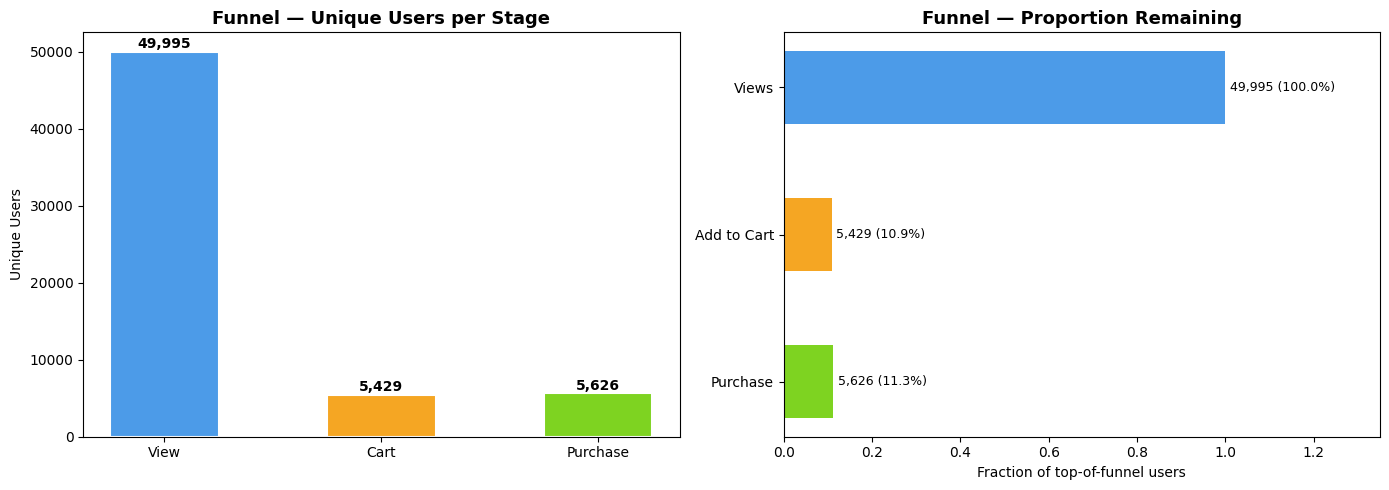

Saved to outputs/02_funnel_chart.png


In [5]:
stages  = ["View", "Cart", "Purchase"]
counts  = [views, carts, purchases]
colors  = ["#4C9BE8", "#F5A623", "#7ED321"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart ---
bars = axes[0].bar(stages, counts, color=colors, width=0.5, edgecolor="white", linewidth=1.5)
axes[0].set_title("Funnel  Unique Users per Stage", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Unique Users")
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(counts) * 0.01,
                 f"{count:,}", ha="center", fontsize=10, fontweight="bold")

# --- Funnel / waterfall ---
drop_view_to_cart     = views - carts
drop_cart_to_purchase = carts - purchases

funnel_stages  = ["Views", "Add to Cart", "Purchase"]
funnel_values  = [views, carts, purchases]
funnel_colors  = ["#4C9BE8", "#F5A623", "#7ED321"]
bar_widths = [v / views for v in funnel_values]

for i, (stage, val, w, c) in enumerate(zip(funnel_stages, funnel_values, bar_widths, funnel_colors)):
    axes[1].barh(i, w, color=c, height=0.5)
    axes[1].text(w + 0.01, i, f"{val:,} ({val/views:.1%})", va="center", fontsize=9)

axes[1].set_yticks(range(3))
axes[1].set_yticklabels(funnel_stages[::-1][::-1])
axes[1].set_xlim(0, 1.35)
axes[1].set_title("Funnel  Proportion Remaining", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Fraction of top-of-funnel users")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../outputs/02_funnel_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/02_funnel_chart.png")

## Step 4  Drop-off volume

Conversion rates are percentages. But percentages hide absolute losses.
A 1% improvement in cart-to-purchase rate could mean thousands of users.
Translate rates into absolute numbers.

In [6]:
lost_at_cart     = views - carts
lost_at_checkout = carts - purchases

print(f"ABSOLUTE DROP-OFF")
print(f"{'─'*45}")
print(f"  Users who viewed but never carted  : {lost_at_cart:,}")
print(f"  Users who carted but never bought  : {lost_at_checkout:,}")
print()

# Impact calculation  what if you improved each rate by 5%?
improved_v2c  = views * (view_to_cart + 0.05)
improved_c2p  = carts * (cart_to_purchase + 0.05)
current_rev   = purchases  # proxy for revenue (1 unit per purchase)
improved_rev1 = improved_v2c * cart_to_purchase
improved_rev2 = views * view_to_cart * (cart_to_purchase + 0.05)

print("IMPACT OF +5% IMPROVEMENT")
print(f"{'─'*45}")
print(f"  If View→Cart improves +5%  → {improved_rev1:,.0f} purchases (was {purchases:,})")
print(f"  If Cart→Purchase +5%       → {improved_rev2:,.0f} purchases (was {purchases:,})")
print()
print("Which improvement has bigger impact?")

ABSOLUTE DROP-OFF
─────────────────────────────────────────────
  Users who viewed but never carted  : 44,566
  Users who carted but never bought  : -197

IMPACT OF +5% IMPROVEMENT
─────────────────────────────────────────────
  If View→Cart improves +5%  → 8,216 purchases (was 5,626)
  If Cart→Purchase +5%       → 5,897 purchases (was 5,626)

Which improvement has bigger impact?


## Checkpoint  What you should know

1. Why do we count unique users instead of events?
2. What is the view-to-cart conversion rate for this dataset?
3. Is it above or below the industry benchmark?
4. If cart-to-purchase is below 20%, what does that suggest about the business?
5. Between improving view-to-cart vs cart-to-purchase  which had bigger impact?

**Do not proceed to Phase 3 until you can answer all 5 from memory.**

---
➡️ Next: `03_dropoff_analysis.ipynb`